::# Softmax activation function and loss functions for classification





<img src='https://drive.google.com/uc?id=1JkI0nvTCsTLFGlSG1nfDYutmxKeR0mmD'>

<details>
  <summary>original </summary>
  https://assets.datacamp.com/production/repositories/4335/datasets/e3ef318a24f6b7c1035a124db67dcd440651e878/multiclass_multilabel.png

</details>


Мультилейбл датасет


*   [link](https://www.kaggle.com/datasets/kaiska/apparel-dataset) kaggle






In [ ]:
!pip install gdown

In [ ]:
!gdown https://drive.google.com/uc?id=1JwtdQeJ-GEg4Iba3KiILUjgAMPLI9JtL -O apparel_small.zip

Downloading...
From (original): https://drive.google.com/uc?id=1JwtdQeJ-GEg4Iba3KiILUjgAMPLI9JtL
From (redirected): https://drive.google.com/uc?id=1JwtdQeJ-GEg4Iba3KiILUjgAMPLI9JtL&confirm=t&uuid=7ed789f1-82f2-43e2-b675-d99537132a72
To: /content/apparel_small.zip
100% 61.8M/61.8M [00:00<00:00, 63.6MB/s]


In [ ]:
!unzip -d dataset apparel_small.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/black_pants/447.jpg  
  inflating: dataset/black_pants/394.jpg  
  inflating: dataset/black_pants/477.jpg  
  inflating: dataset/black_pants/374.jpg  
  inflating: dataset/black_pants/453.jpg  
  inflating: dataset/black_pants/196.jpg  
  inflating: dataset/black_pants/698.jpg  
  inflating: dataset/black_pants/337.jpg  
  inflating: dataset/black_pants/233.jpg  
  inflating: dataset/black_pants/221.jpg  
  inflating: dataset/black_pants/720.jpg  
  inflating: dataset/black_pants/824.jpg  
  inflating: dataset/black_pants/286.jpg  
  inflating: dataset/black_pants/327.jpg  
  inflating: dataset/black_pants/277.jpg  
  inflating: dataset/black_pants/379.jpg  
  inflating: dataset/black_pants/620.jpg  
  inflating: dataset/black_pants/89.jpg  
  inflating: dataset/black_pants/12.jpg  
  inflating: dataset/black_pants/80.jpg  
  inflating: dataset/black_pants/240.jpg  
  inflating: dataset/black_pants/700.jpg  
  infl

In [ ]:
import os

paths = []
for dirname, _, filenames in os.walk('dataset/'):
    print(dirname, _, filenames)
    for filename in filenames:
        paths.append(os.path.join(dirname, filename))

paths = sorted(paths)
paths[:10]

dataset/ ['white_pants', 'white_dress', 'black_pants', 'white_shoes', 'black_shoes', 'blue_dress', 'blue_pants', 'black_dress', 'blue_shoes'] []
dataset/white_pants [] ['257.jpg', '99.jpg', '52.jpg', '109.jpg', '225.jpg', '171.jpg', '101.jpg', '167.jpg', '66.jpg', '238.jpg', '212.jpg', '82.jpg', '91.jpg', '9.jpg', '265.jpg', '163.jpg', '199.jpg', '201.jpg', '72.jpg', '223.jpg', '2.jpg', '138.jpg', '28.jpg', '228.jpg', '259.jpg', '233.jpg', '250.jpg', '197.jpg', '269.jpg', '108.jpg', '235.jpg', '134.jpg', '217.jpg', '155.jpg', '57.jpg', '94.jpg', '75.jpg', '154.jpg', '33.jpg', '247.jpg', '62.jpg', '89.jpg', '274.jpg', '178.jpg', '13.jpg', '93.jpg', '220.jpg', '142.jpg', '36.jpg', '45.jpg', '251.jpg', '232.jpg', '32.jpg', '92.jpg', '42.jpg', '146.jpg', '207.jpg', '49.jpg', '186.jpg', '67.jpg', '260.jpg', '271.jpg', '264.jpg', '151.jpg', '132.jpg', '208.jpg', '234.jpg', '174.jpg', '226.jpg', '219.jpg', '81.jpg', '85.jpg', '105.jpg', '165.jpg', '125.jpg', '268.jpg', '102.jpg', '3.jpg', '38

['dataset/black_dress/1.jpg',
 'dataset/black_dress/10.jpg',
 'dataset/black_dress/100.jpg',
 'dataset/black_dress/101.jpg',
 'dataset/black_dress/102.jpg',
 'dataset/black_dress/103.jpg',
 'dataset/black_dress/104.jpg',
 'dataset/black_dress/105.jpg',
 'dataset/black_dress/106.jpg',
 'dataset/black_dress/107.jpg']

In [ ]:
len(paths)

5601

dataset/black_dress/10.jpg
(256, 256, 3)


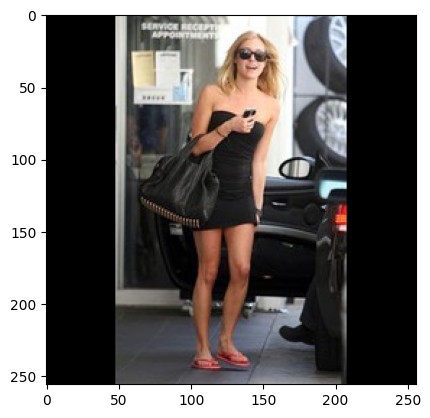

In [ ]:
import matplotlib.pyplot as plt

idx = 1
print(paths[idx])
img = plt.imread(paths[idx])
print(img.shape)
plt.imshow(img);

In [ ]:
paths[:10]

['dataset/black_dress/1.jpg',
 'dataset/black_dress/10.jpg',
 'dataset/black_dress/100.jpg',
 'dataset/black_dress/101.jpg',
 'dataset/black_dress/102.jpg',
 'dataset/black_dress/103.jpg',
 'dataset/black_dress/104.jpg',
 'dataset/black_dress/105.jpg',
 'dataset/black_dress/106.jpg',
 'dataset/black_dress/107.jpg']

In [ ]:
import numpy as np

np.random.seed(1)
np.random.shuffle(paths)

In [ ]:
paths[:10]

['dataset/white_dress/815.jpg',
 'dataset/white_shoes/72.jpg',
 'dataset/black_dress/324.jpg',
 'dataset/black_shoes/466.jpg',
 'dataset/blue_pants/119.jpg',
 'dataset/black_pants/750.jpg',
 'dataset/white_shoes/559.jpg',
 'dataset/white_dress/793.jpg',
 'dataset/white_pants/187.jpg',
 'dataset/black_pants/210.jpg']

In [ ]:
train_size = 0.7

thresh = round(len(paths) * train_size)

train_paths = paths[:thresh]
test_paths = paths[thresh:]

len(train_paths), len(test_paths)

(3921, 1680)

The class is specified in the path to the image, so you need to get it.

In [ ]:
paths[0]

'dataset/white_dress/815.jpg'

In [ ]:
paths[0].split('/')[-2]

'white_dress'

And since we have a multi-label, we need to separate the two classes from each other.

In [ ]:
paths[0].split('/')[-2].split('_')

['white', 'dress']

In [ ]:
train_labels = []

for path in train_paths:
    label = path.split('/')[-2].split('_')
    train_labels.append(label)

train_labels[:10]

[['white', 'dress'],
 ['white', 'shoes'],
 ['black', 'dress'],
 ['black', 'shoes'],
 ['blue', 'pants'],
 ['black', 'pants'],
 ['white', 'shoes'],
 ['white', 'dress'],
 ['white', 'pants'],
 ['black', 'pants']]

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer


mlb = MultiLabelBinarizer()
train_classes = mlb.fit_transform(train_labels)
train_classes

array([[0, 0, 1, 0, 0, 1],
       [0, 0, 0, 0, 1, 1],
       [1, 0, 1, 0, 0, 0],
       ...,
       [1, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 1],
       [1, 0, 0, 1, 0, 0]])

In [ ]:
classes_names = mlb.classes_
classes_names

array(['black', 'blue', 'dress', 'pants', 'shoes', 'white'], dtype=object)

In [ ]:
import pandas as pd

tmp = pd.DataFrame(train_classes, columns=mlb.classes_)
tmp['labels'] = train_labels
tmp

,black,blue,dress,pants,shoes,white,labels
0,0,0,1,0,0,1,"[white, dress]"
1,0,0,0,0,1,1,"[white, shoes]"
2,1,0,1,0,0,0,"[black, dress]"
3,1,0,0,0,1,0,"[black, shoes]"
4,0,1,0,1,0,0,"[blue, pants]"
...,...,...,...,...,...,...,...
3916,1,0,1,0,0,0,"[black, dress]"
3917,0,1,0,1,0,0,"[blue, pants]"
3918,1,0,0,1,0,0,"[black, pants]"
3919,0,0,0,1,0,1,"[white, pants]"


Затем тоже самое с тестовой выборкой

In [ ]:
test_labels = []
for path in test_paths:
    label = path.split('/')[-2].split('_')
    test_labels.append(label)

test_classes = mlb.transform(test_labels)
test_classes

array([[0, 1, 0, 1, 0, 0],
       [0, 1, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 1],
       ...,
       [0, 0, 1, 0, 0, 1],
       [1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1]])

The original images are 256x256 in size. To make it easier to train the network, we will compress the images to 64x64.

In [ ]:
img[np.newaxis, ...].shape

(1, 256, 256, 3)

In [ ]:
import tensorflow as tf

img_resized = tf.image.resize(img[np.newaxis, ...], (64, 64), method='nearest')
img_resized.shape

TensorShape([1, 64, 64, 3])

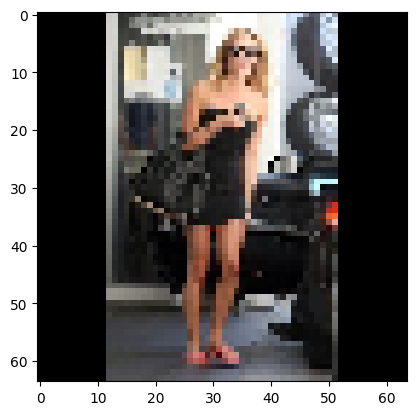

In [ ]:
plt.imshow(img_resized[0]);

In [ ]:
np.array(img_resized).min(), np.array(img_resized).max()

(np.uint8(0), np.uint8(255))

In [ ]:
from tensorflow.keras.utils import Sequence


class DataGenerator(Sequence):
    def __init__(self, paths, labels, batch_size=32):
        self.batch_size = batch_size
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return int(np.round(len(self.paths) / self.batch_size))

    def __getitem__(self, index):
        X = self.paths[index * self.batch_size : (index+1) * self.batch_size]
        y = self.labels[index * self.batch_size : (index+1) * self.batch_size]
        X = np.array([self.load_img(i) for i in X])
        return X, y

    @staticmethod
    def load_img(path):
        img = plt.imread(path)[np.newaxis, ...]
        img_resized = tf.image.resize(img, (64, 64), method='nearest')[0]
        img_resized = np.array(img_resized, dtype='float')
        img_resized /= 255.0
        return img_resized

In [ ]:
train_datagen = DataGenerator(train_paths, train_classes)
test_datagen = DataGenerator(test_paths, test_classes)

In [ ]:
len(train_datagen)

123

In [ ]:
len(test_datagen)

52

(32, 64, 64, 3)
(32, 6)
[0 0 1 0 0 1]


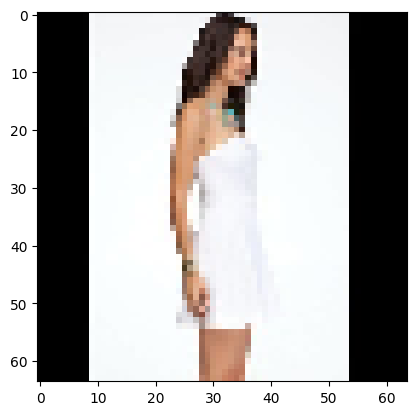

In [ ]:
for X, y in train_datagen:
    print(X.shape)
    plt.imshow(X[0])
    print(y.shape)
    print(y[0])
    break

In [ ]:
classes_names[y[0].astype('bool')]

array(['dress', 'white'], dtype=object)

In [ ]:
from keras.models import Model
from keras.layers import Input, Flatten, Dense

tf.random.set_seed(9)

input = Input(shape=(64, 64, 3))
flatten = Flatten()(input)
output = Dense(6, activation='softmax')(flatten)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        73,734 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,734 (288.02 KB)

 Trainable params: 73,734 (288.02 KB)

 Non-trainable params: 0 (0.00 B)

We can see that a large number of weights are generated, and we are only using one layer. If we create more layers, there will be even more weights.

In [ ]:
from keras import losses

model.compile(
    optimizer='adam',
    loss=losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

**Clarification about CategoricalCrossentropy/SparseCategoricalCrossentropy:**

1. If the target values are represented as LabelEncoder:

```
[5, 0, 4, 1, 2]

```

use **SparseCategoricalCrossentropy**
2. If the target values are represented as OHE:

```
[[0., 0., 0., 0., 0., 1.],
[1., 0., 0., 0., 0., 0.],
[0., 0., 0., 0., 1., 0.],
[0., 1., 0., 0., 0., 0.],
[0., 0., 1., 0., 0., 0.]]

```

use **CategoricalCrossentropy**

In [ ]:
model.fit(
    train_datagen,
    epochs=5,
    validation_data=test_datagen
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.1895 - loss: 4.6085 - val_accuracy: 0.2927 - val_loss: 4.9199
Epoch 2/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.2762 - loss: 4.1617 - val_accuracy: 0.2284 - val_loss: 4.2094
Epoch 3/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 25s 203ms/step - accuracy: 0.2798 - loss: 4.5122 - val_accuracy: 0.3528 - val_loss: 4.5534
Epoch 4/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 24s 196ms/step - accuracy: 0.2905 - loss: 5.2675 - val_accuracy: 0.4195 - val_loss: 5.1974
Epoch 5/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 30s 103ms/step - accuracy: 0.3416 - loss: 5.9437 - val_accuracy: 0.2788 - val_loss: 5.4995


In [ ]:
for X, y in test_datagen:
    print(X.shape)
    print(y.shape)
    break

(32, 64, 64, 3)
(32, 6)


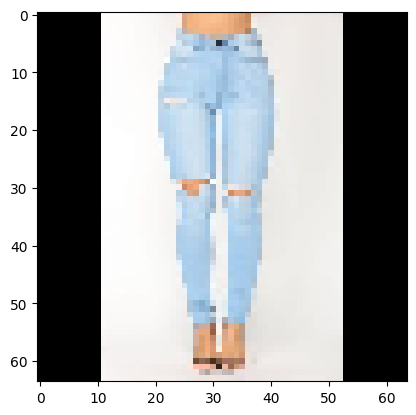

In [ ]:
idx = 0
plt.imshow(X[idx]);

In [ ]:
y[idx]

array([0, 1, 0, 1, 0, 0])

In [ ]:
classes_names[y[idx].astype('bool')]

array(['blue', 'pants'], dtype=object)

In [ ]:
preds = model.predict(X[[idx]])[0]
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


array([0.00123146, 0.30719596, 0.110124  , 0.33829606, 0.001147  ,
       0.2420055 ], dtype=float32)

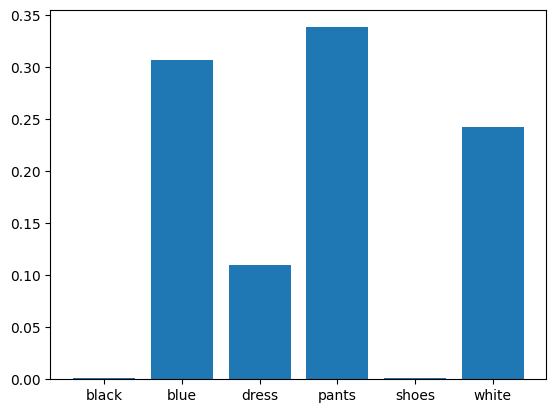

In [ ]:
plt.bar(np.arange(len(preds)), preds)
plt.xticks(np.arange(len(preds)), classes_names);

### TRAINING WITH sigmoid+binary_crossentropy

According to predictions, the results are not very good
* First, the network is too weak, and if we add more layers, it will take a long time to train it
* Second, the output is a softmax activation function, but we need to use sigmoid, since there can be two classes in one image
* Third, since we have multi-label classification, we need to train it using binary cross-entropy to learn to predict the probability of being or not being each class.

In [ ]:
from keras.models import Model
from keras.layers import Input, Flatten, Dense

tf.random.set_seed(9)

input = Input(shape=(64, 64, 3))
flatten = Flatten()(input)
output = Dense(6, activation='sigmoid')(flatten)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │        73,734 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,734 (288.02 KB)

 Trainable params: 73,734 (288.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import losses

model.compile(
    optimizer='adam',
    loss=losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_datagen,
    epochs=5,
    validation_data=test_datagen
)

Epoch 1/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.2114 - loss: 0.6614 - val_accuracy: 0.3684 - val_loss: 0.3741
Epoch 2/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.2699 - loss: 0.3628 - val_accuracy: 0.2897 - val_loss: 0.3453
Epoch 3/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.3126 - loss: 0.3171 - val_accuracy: 0.3726 - val_loss: 0.2894
Epoch 4/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.3558 - loss: 0.3191 - val_accuracy: 0.2903 - val_loss: 0.3191
Epoch 5/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.3550 - loss: 0.2763 - val_accuracy: 0.3870 - val_loss: 0.3034


In [ ]:
for X, y in test_datagen:
    print(X.shape)
    print(y.shape)
    break

(32, 64, 64, 3)
(32, 6)


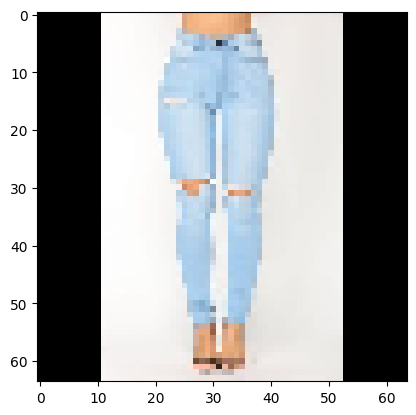

In [ ]:
idx = 0
plt.imshow(X[idx]);

In [ ]:
y[idx]

array([0, 1, 0, 1, 0, 0])

In [ ]:
classes_names[y[idx].astype('bool')]

array(['blue', 'pants'], dtype=object)

In [ ]:
preds = model.predict(X[[idx]])[0]
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


array([1.5982975e-04, 9.4979346e-01, 1.7911835e-01, 7.6808292e-01,
       7.4247383e-03, 5.6274209e-02], dtype=float32)

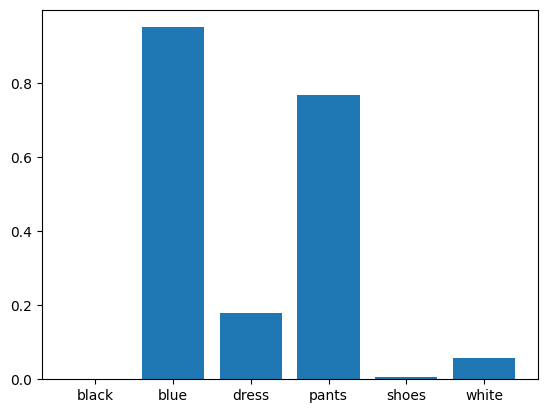

In [ ]:
plt.bar(np.arange(len(preds)), preds)
plt.xticks(np.arange(len(preds)), classes_names);

In [ ]:
classes_names[np.where(preds > 0.5)]

array(['blue', 'pants'], dtype=object)

In [ ]:
model.evaluate(test_datagen)

52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.3793 - loss: 0.3203


[0.30337193608283997, 0.38701921701431274]